In [1]:
!pip install boto3 seaborn matplotlib pandas numpy pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 1.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 12.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.3 MB/s eta 0:00:00


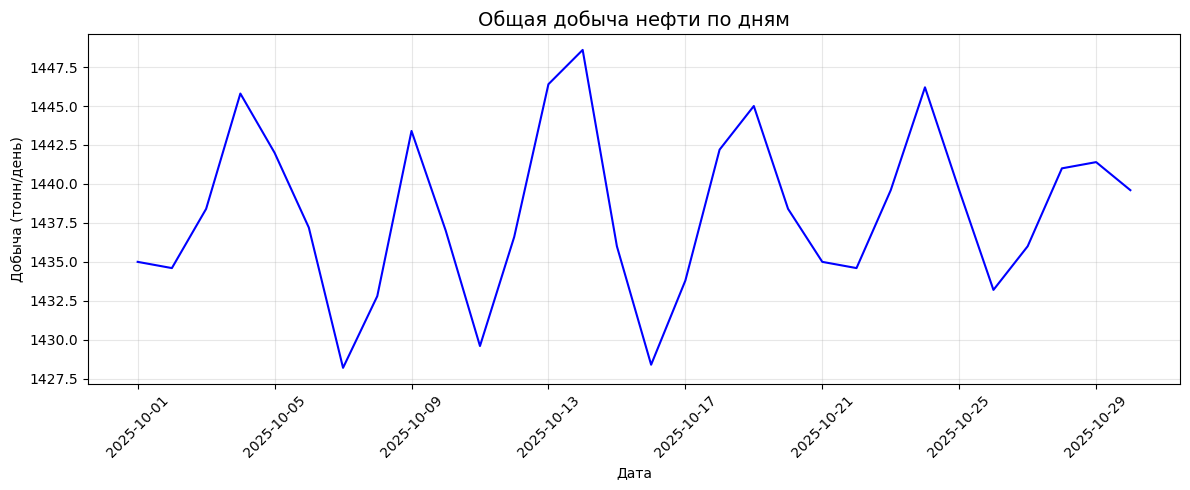


KPI по скважинам
         avg_oil_rate  total_oil  max_oil  avg_water   avg_gas
well_id                                                       
1              213.15    12789.0    215.2     182.43  55218.33
2              185.82    11149.0    187.3     161.36  49772.67
3              121.70     7301.8    123.2     121.08  40150.00
4                0.00        0.0      0.0       0.00      0.00
5              198.43    11905.8    199.3     165.98  52258.33

Лучшие скважины
         avg_oil_rate
well_id              
1              213.15
5              198.43

Худшие скважины
         avg_oil_rate
well_id              
4                 0.0
3               121.7


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from io import BytesIO

s3_client = boto3.client(
    's3',
    endpoint_url='http://minio:9000',
    aws_access_key_id='minioadmin',
    aws_secret_access_key='minioadmin',
    region_name='us-east-1'
)

bucket_name = 'oil-data'

def read_parquet_from_minio(key):
    obj = s3_client.get_object(Bucket=bucket_name, Key=key)
    return pd.read_parquet(BytesIO(obj['Body'].read()))

wells = read_parquet_from_minio('raw/wells/data.parquet')

production_dfs = []
response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix='raw/production/')
for obj in response.get('Contents', []):
    if obj['Key'].endswith('.parquet'):
        df = read_parquet_from_minio(obj['Key'])
        production_dfs.append(df)
production = pd.concat(production_dfs, ignore_index=True)

well_telemetry_dfs = []
response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix='raw/well_telemetry/')
for obj in response.get('Contents', []):
    if obj['Key'].endswith('.parquet'):
        df = read_parquet_from_minio(obj['Key'])
        well_telemetry_dfs.append(df)
well_telemetry = pd.concat(well_telemetry_dfs, ignore_index=True)


daily_production = production.groupby('date')['oil_ton'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(daily_production['date'], daily_production['oil_ton'], color='blue')
plt.title('Общая добыча нефти по дням', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Добыча (тонн/день)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('daily_production.png')
plt.show()

well_kpi = production.groupby('well_id').agg({
    'oil_ton': ['mean', 'sum', 'max'],
    'water_m3': 'mean',
    'gas_m3': 'mean'
}).round(2)
well_kpi.columns = ['avg_oil_rate', 'total_oil', 'max_oil', 'avg_water', 'avg_gas']

print("\nKPI по скважинам")
print(well_kpi)

best_wells = well_kpi.nlargest(2, 'avg_oil_rate')
worst_wells = well_kpi.nsmallest(2, 'avg_oil_rate')

print("\nЛучшие скважины")
print(best_wells[['avg_oil_rate']])

print("\nХудшие скважины")
print(worst_wells[['avg_oil_rate']])

